In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("student_info.csv")
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [3]:
df.shape

(200, 2)

In [4]:
df.size

400

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [6]:
df.duplicated

<bound method DataFrame.duplicated of      study_hours  student_marks
0           6.83          78.50
1           6.56          76.74
2            NaN          78.68
3           5.67          71.82
4           8.67          84.19
..           ...            ...
195         7.53          81.67
196         8.56          84.68
197         8.94          86.75
198         6.60          78.05
199         8.35          83.50

[200 rows x 2 columns]>

In [7]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [8]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [9]:
df.fillna(df.mean(),inplace=True)

In [10]:
df.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [11]:
x = df.drop("student_marks",axis = 1)
y = df["student_marks"]

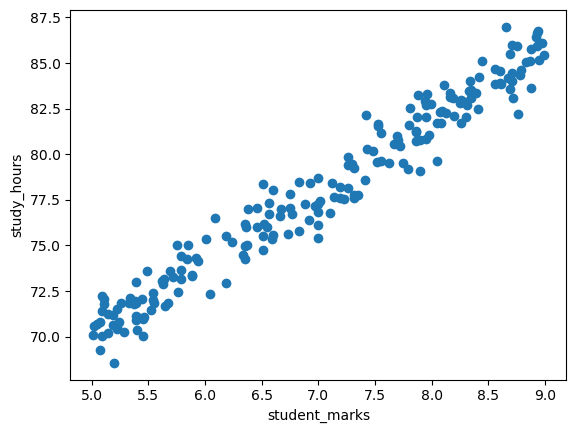

In [12]:
import matplotlib.pyplot as plt
plt.scatter(x = df.study_hours, y = df.student_marks)
plt.xlabel("student_marks")
plt.ylabel("study_hours")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [31]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [35]:
lr.score(x_train,y_train)

0.9542138375790685

In [60]:
print("When You Study per day then your Score Will be: ",lr.predict([[8]]))

When You Study per day then your Score Will be:  [81.86330563]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [62]:
y_pred = lr.predict(x_test)
y_pred

array([70.22862554, 81.78522053, 76.35830599, 81.70713543, 77.94323333,
       84.47915653, 85.45522029, 81.66809288, 83.03458215, 70.18958299,
       83.1517098 , 78.42756118, 70.4238383 , 73.43011469, 70.5019234 ,
       85.29905009, 82.17564604, 77.94323333, 72.18075307, 74.75756142,
       70.5019234 , 74.99181672, 76.04596559, 80.88724187, 73.23490194,
       71.63415737, 85.29905009, 81.31670992, 77.0610719 , 81.08245462,
       71.08756166, 76.63160385, 81.47288013, 72.68830623, 75.42128478,
       85.49426284, 84.20585867, 73.5862849 , 71.71224247, 73.8205402 ])

In [66]:
pd.DataFrame(np.c_[x_test,y_test,y_pred],columns =["Study_hours","Students_Marks_Orignale",
                                                   "Students_Marks_predicted!"])

,Study_hours,Students_Marks_Orignale,Students_Marks_predicted!
0,5.020000,70.58,70.228626
1,7.980000,81.08,81.785221
2,6.590000,75.37,76.358306
3,7.960000,83.33,81.707135
4,6.995949,78.68,77.943233
5,8.670000,84.19,84.479157
6,8.920000,86.41,85.455220
7,7.950000,82.68,81.668093
8,8.300000,82.02,83.034582
9,5.010000,70.11,70.189583


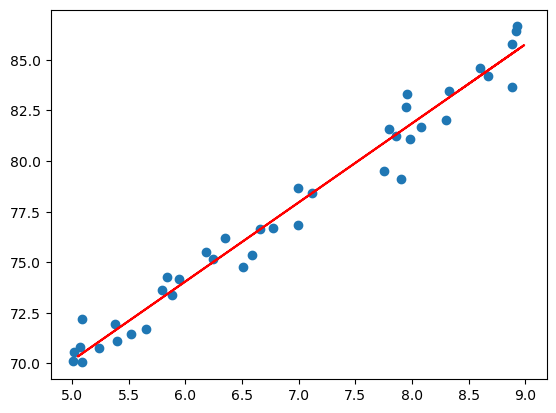

In [76]:
plt.scatter(x_test,y_test)
plt.plot(x_train, lr.predict(x_train),color="r")
plt.show()

In [80]:
import joblib 
joblib.dump(lr,"Students_Marks_predict_model.pkl")


['Students_Marks_predict_model.pkl']

In [82]:
model = joblib.load("Students_Marks_predict_model.pkl")

In [84]:
model.predict([[5]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([70.15054044])